# Dia 1 · Módulo 1 — Medidas de Tendência Central
### Estatística Básica Aplicada · Python

Todo mundo nesta sala sabe calcular uma média. Então este módulo **não** é sobre isso.
A pergunta aqui é outra:

> ## Por que existe mais de uma medida de centro?
> ## E o que cada uma faz que as outras **não conseguem fazer**?

Média, mediana e moda não são três receitas para a mesma coisa. Elas são as respostas
**ótimas** para três perguntas diferentes — e a resposta certa muda conforme o custo de
errar, a escala em que o dado foi medido e o que você vai fazer com o número depois.

**O que a turma vai levar deste módulo:**
1. Cada medida de centro é o resultado de **minimizar um tipo de erro** — e você escolhe qual erro.
2. Cada uma tem uma **propriedade exclusiva** que as outras não têm (total, agregação, escala, robustez).
3. Robustez **tem preço**: a mediana custa precisão. Existe um dial contínuo entre as duas.
4. Existem outras médias (**geométrica**, **harmônica**) — e usar a errada dá resposta errada.
5. Às vezes **o centro simplesmente não existe** — e insistir nele é o erro mais caro de todos.

> ⚠️ Ninguém precisa escrever código do zero. O código já está pronto e comentado.
> Seu trabalho é: **ler → prever o resultado → rodar → interpretar → modificar**.

## Roteiro e tempo

| Seção | Assunto | Ideia central |
|---|---|---|
| ⓪ | O jogo do palpite único | as três medidas **nascem** de três definições de erro |
| ① | A propriedade exclusiva de cada uma | por que nenhuma pode ser aposentada |
| ② | Robustez tem preço | ponto de ruptura × eficiência; o dial contínuo |
| ③ | A família das médias | aritmética, geométrica, harmônica |
| ④ | Quando o centro não existe | bimodalidade e o "militar médio" |
| ⑤ | Decisão e comunicação | o que reportar ao comando |

As seções ③ e ④ são **aprofundamento** — se o tempo apertar, elas podem virar leitura dirigida.

In [1]:
# --- Preparação do ambiente ---
# numpy: cálculos numéricos | pandas: tabelas | matplotlib: gráficos | scipy: estatística
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)   # 'semente' fixa: todos geram exatamente os mesmos dados aleatórios

# Paleta do curso: cada CONCEITO tem sempre a MESMA cor, em todos os gráficos.
COR = {
    "media":   "#2a78d6",   # azul
    "mediana": "#eb6834",   # laranja
    "moda":    "#1baf7a",   # verde-água
    "aparada": "#4a3aa7",   # violeta  (média aparada — seção 2)
    "dados":   "#9ec5f4",   # azul claro (barras e histogramas)
}

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "axes.labelcolor": "#52514e", "xtick.color": "#898781", "ytick.color": "#898781",
    "font.size": 10, "lines.linewidth": 2, "figure.dpi": 110,
})

print("Ambiente pronto.")

Ambiente pronto.


## Nossos dados: o TAF de um pelotão

**Teste de Aptidão Física (TAF)** de um pelotão de 12 militares:

- `tempo_corrida_min` — tempo (em minutos) na corrida de 3 km.
- `flexoes` — número de flexões de braço executadas.

O **Soldado 12** estava **lesionado**: fez um tempo muito acima dos demais. Guarde esse detalhe.

In [2]:
# --- Base de dados do pelotão ---
# 11 militares com desempenho "normal" + 1 lesionado (tempo muito alto)
tempos  = [12.8, 13.5, 12.1, 14.0, 13.2, 12.9, 13.7, 12.4, 13.9, 13.1, 12.6, 22.0]
#                                                                          ^ Sd 12 (lesionado)
flexoes = [  42,   38,   45,   40,   38,   41,   38,   44,   39,   38,   43,   20]

pelotao = pd.DataFrame({
    "soldado": [f"Sd {i}" for i in range(1, 13)],
    "tempo_corrida_min": tempos,
    "flexoes": flexoes,
})

# atalhos usados o notebook inteiro
t = pelotao["tempo_corrida_min"].to_numpy()   # tempos
f = pelotao["flexoes"].to_numpy()             # flexões

pelotao

,soldado,tempo_corrida_min,flexoes
0,Sd 1,12.8,42
1,Sd 2,13.5,38
2,Sd 3,12.1,45
3,Sd 4,14.0,40
4,Sd 5,13.2,38
5,Sd 6,12.9,41
6,Sd 7,13.7,38
7,Sd 8,12.4,44
8,Sd 9,13.9,39
9,Sd 10,13.1,38


---
# ⓪ O jogo do palpite único

Esqueça as fórmulas por um minuto. Situação:

> O comando vai te dar **os 12 valores de flexões**, e você precisa devolver **um único número**
> que represente o pelotão. Depois, para cada militar, você vai **pagar uma multa** proporcional
> ao quanto o seu palpite errou o valor real dele.

A pergunta decisiva é: **como a multa é cobrada?** Existem três contratos possíveis:

| Contrato | Multa por militar | Como isso se comporta |
|---|---|---|
| **A** | `(erro)²` — erro ao **quadrado** | errar por 10 custa **100×** mais que errar por 1 |
| **B** | `\|erro\|` — erro em **módulo** | errar por 10 custa **10×** mais que errar por 1 |
| **C** | `0 se acertou na mosca, 1 se errou` | errar por 1 custa **o mesmo** que errar por 40 |

Cada contrato tem um palpite ótimo diferente. Vamos **procurar esse palpite na força bruta**:
testar todos os valores possíveis e ver qual dá a menor multa total.

**Antes de rodar, aposte:** o palpite ótimo do contrato C (só conta se acertou na mosca)
vai ser qual número?

In [3]:
# --- Força bruta: testamos TODOS os palpites de 19 a 46 e medimos a multa total ---
grade = np.round(np.arange(19, 46.001, 0.01), 2)   # candidatos a "melhor palpite"

custo_A = np.array([np.sum((f - c) ** 2)     for c in grade])   # erro ao quadrado
custo_B = np.array([np.sum(np.abs(f - c))    for c in grade])   # erro em módulo
custo_C = np.array([np.sum(f != c)           for c in grade])   # nº de militares que você NÃO acertou

empatados_B = grade[custo_B == custo_B.min()]   # o contrato B tem MAIS DE UM vencedor (veja abaixo)

print("PALPITE VENCEDOR DE CADA CONTRATO (achado na força bruta):")
print(f"  A · minimiza Σ(erro)²    ->  {grade[custo_A.argmin()]:.2f}")
print(f"  B · minimiza Σ|erro|     ->  empate técnico de {empatados_B.min():.2f} a {empatados_B.max():.2f}"
      f"  (meio do intervalo = {(empatados_B.min() + empatados_B.max()) / 2:.2f})")
print(f"  C · minimiza nº de erros ->  {grade[custo_C.argmin()]:.2f}")

print("\nAGORA AS FÓRMULAS QUE VOCÊ JÁ CONHECE:")
print(f"  média   = {f.mean():.2f}")
print(f"  mediana = {np.median(f):.2f}")
print(f"  moda    = {pd.Series(f).mode().iloc[0]}")

PALPITE VENCEDOR DE CADA CONTRATO (achado na força bruta):


  A · minimiza Σ(erro)²    ->  38.83
  B · minimiza Σ|erro|     ->  empate técnico de 39.00 a 40.00  (meio do intervalo = 39.50)
  C · minimiza nº de erros ->  38.00

AGORA AS FÓRMULAS QUE VOCÊ JÁ CONHECE:
  média   = 38.83
  mediana = 39.50
  moda    = 38


### O que acabou de acontecer

Não houve coincidência. Isto é um **teorema**, não um acaso dos dados:

- A **média** é o número que minimiza a soma dos erros **ao quadrado**.
- A **mediana** é o número que minimiza a soma dos erros **absolutos**.
- A **moda** é o número que minimiza a **quantidade** de erros (o famoso "chutar o mais comum").

> ### 🔑 A ideia central do módulo
> Você não escolhe uma medida de centro. Você escolhe **como o erro te machuca** —
> e a medida cai como consequência.
>
> Se errar feio é **desproporcionalmente** caro (combustível, munição, dimensionamento de
> estrutura) → o quadrado pune o erro grande → **média**.
> Se errar feio é caro **na proporção** (atraso em minutos, custo por km) → **mediana**.
> Se só existe "acertou ou não acertou" (qual fuzil, qual tipo sanguíneo) → **moda**.

Repare também no contrato B: o vencedor **não foi único**.

In [4]:
# --- Por que o contrato B empatou? Porque n = 12 é PAR ---
print(f"n = 12 (PAR)  -> vencedores do contrato B: de {empatados_B.min():.2f} a {empatados_B.max():.2f} (empate)")
print(f"                 mediana pela convenção do meio: {np.median(f):.2f}")
print()

# Refazendo com 11 militares (n ÍMPAR): existe um valor "do meio" de verdade
f_impar = f[:11]
custo_B_impar = np.array([np.sum(np.abs(f_impar - c)) for c in grade])
vencedores = grade[custo_B_impar == custo_B_impar.min()]

print(f"n = 11 (ÍMPAR)-> vencedores do contrato B: {vencedores}  (um só!)")
print(f"                 mediana: {np.median(f_impar):.2f}")
print()
print("Com n ÍMPAR a mediana é um valor REALMENTE OBSERVADO — algum militar fez exatamente aquilo.")
print("Com n PAR ela é um valor INVENTADO: a média dos dois centrais, escolhida por convenção")
print("no meio de um intervalo de empate. Vale lembrar disso ao reportar 'a mediana foi 39,5 flexões'.")

n = 12 (PAR)  -> vencedores do contrato B: de 39.00 a 40.00 (empate)
                 mediana pela convenção do meio: 39.50

n = 11 (ÍMPAR)-> vencedores do contrato B: [40.]  (um só!)
                 mediana: 40.00

Com n ÍMPAR a mediana é um valor REALMENTE OBSERVADO — algum militar fez exatamente aquilo.
Com n PAR ela é um valor INVENTADO: a média dos dois centrais, escolhida por convenção
no meio de um intervalo de empate. Vale lembrar disso ao reportar 'a mediana foi 39,5 flexões'.


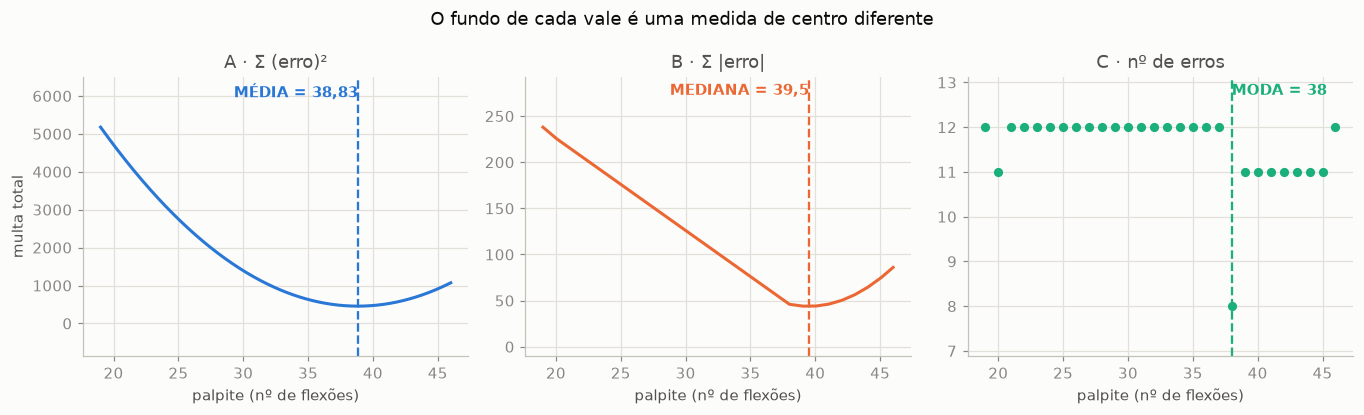

In [5]:
# --- As três curvas de custo, lado a lado ---
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8), sharex=True)

# no contrato C só faz sentido palpitar números inteiros de flexões
inteiros = np.arange(19, 47)
custo_C_int = np.array([np.sum(f != c) for c in inteiros])

paineis = [
    ("linha",  grade,    custo_A,     "A · Σ (erro)²",   "MÉDIA = 38,83",   f.mean(),                    COR["media"]),
    ("linha",  grade,    custo_B,     "B · Σ |erro|",    "MEDIANA = 39,5",  np.median(f),                COR["mediana"]),
    ("pontos", inteiros, custo_C_int, "C · nº de erros", "MODA = 38",       pd.Series(f).mode().iloc[0], COR["moda"]),
]

for ax, (tipo, eixo_x, custo, titulo, nome, vencedor, cor) in zip(axes, paineis):
    if tipo == "linha":
        ax.plot(eixo_x, custo, color=cor)
    else:
        ax.plot(eixo_x, custo, color=cor, marker="o", markersize=5, linestyle="none")
    ax.axvline(vencedor, color=cor, linestyle="--", linewidth=1.5)
    ax.margins(y=0.28)                                   # espaço no topo para o rótulo
    ax.annotate(nome,
                xy=(vencedor, 1.0), xycoords=("data", "axes fraction"),
                xytext=(0, -4), textcoords="offset points",
                color=cor, fontsize=10, fontweight="bold",
                ha="right" if vencedor > 38.5 else "left", va="top")
    ax.set_title(titulo, color="#52514e")
    ax.set_xlabel("palpite (nº de flexões)")

axes[0].set_ylabel("multa total")
fig.suptitle("O fundo de cada vale é uma medida de centro diferente", fontsize=12, color="#0b0b0b")
fig.tight_layout()
plt.show()

Três curvas, três vales, três medidas. **A mesma variável, os mesmos 12 militares.**
O que mudou foi só a régua do erro.

Note ainda o *formato* de cada vale — ele já antecipa a seção 2:
- o vale de A é uma **parábola**: puxar um dado para longe inclina a curva inteira e o fundo escorrega junto;
- o vale de B tem **quinas** e é feito de retas: mexer num extremo muda a inclinação lá na ponta, não onde está o fundo;
- o de C é uma **escada**: só a contagem importa.

---
# ① A propriedade exclusiva de cada medida

Se a mediana é tão mais segura, por que a média não foi aposentada há 200 anos?
Porque cada medida faz **uma coisa que as outras são incapazes de fazer**.

## 1.1 · Só a média conversa com o **total**

A média é a única que carrega a informação da **soma**: `média × n = total`.
Sempre que a pergunta real for de **logística** — quanta ração, quantas horas-homem, quanto
combustível, qual o custo agregado — a mediana é literalmente inútil.

In [6]:
# --- Reconstruindo o total do pelotão a partir de cada medida ---
n = len(f)
print(f"Total REAL de flexões do pelotão: {f.sum()}")
print()
print(f"  {n} × média   = {n * f.mean():.0f}   <- bate exatamente")
print(f"  {n} × mediana = {n * np.median(f):.0f}   <- não bate (erro de {n * np.median(f) - f.sum():.0f} flexões)")
print(f"  {n} × moda    = {n * pd.Series(f).mode().iloc[0]:.0f}   <- não bate")
print()
print("Se o comando pergunta 'quantas rações o pelotão consome por mês?',")
print("a média É a resposta certa — mesmo com outlier. A pergunta é sobre o TOTAL.")

Total REAL de flexões do pelotão: 466

  12 × média   = 466   <- bate exatamente
  12 × mediana = 474   <- não bate (erro de 8 flexões)
  12 × moda    = 456   <- não bate

Se o comando pergunta 'quantas rações o pelotão consome por mês?',
a média É a resposta certa — mesmo com outlier. A pergunta é sobre o TOTAL.


- Média ou Mediana? Se você está preocupado com o total, pense na média. Se voce está preocupado em saber o comportamento de cada militar, pense na mediana.

## 1.2 · Só a média se **agrega** entre grupos

Você tem a média do 1º GC e a média do 2º GC. Quer a média do pelotão inteiro?
Basta a **média ponderada** pelos efetivos. Isso é o que permite consolidar relatórios de baixo
para cima — do GC para o pelotão, do pelotão para a companhia, da companhia para o batalhão.

Com mediana, **não existe fórmula equivalente**. Para saber a mediana do batalhão você precisa
dos dados individuais de todo mundo, de novo.

In [7]:
# --- Consolidando dois grupos de combate no pelotão ---
gc1 = np.array([22.0, 14.0])                                              # 2 militares (o lesionado + 1)
gc2 = np.array([12.8, 13.5, 12.1, 13.2, 12.9, 13.7, 12.4, 13.9, 13.1, 12.6])  # os outros 10
pelotao_todo = np.concatenate([gc1, gc2])

media_consolidada   = (len(gc1) * gc1.mean()      + len(gc2) * gc2.mean())      / len(pelotao_todo)
mediana_consolidada = (len(gc1) * np.median(gc1)  + len(gc2) * np.median(gc2))  / len(pelotao_todo)

print(f"MÉDIA   real (com todos os dados) : {pelotao_todo.mean():.4f}")
print(f"MÉDIA   consolidada dos 2 grupos  : {media_consolidada:.4f}   <- idêntica ✅")
print()
print(f"MEDIANA real (com todos os dados) : {np.median(pelotao_todo):.4f}")
print(f"'mediana consolidada' dos 2 grupos: {mediana_consolidada:.4f}   <- errada ❌")
print()
print("E não é questão de achar a fórmula certa: a mediana do todo NÃO é função")
print("das medianas das partes. Essa informação simplesmente não está lá.")

MÉDIA   real (com todos os dados) : 13.8500
MÉDIA   consolidada dos 2 grupos  : 13.8500   <- idêntica ✅

MEDIANA real (com todos os dados) : 13.1500
'mediana consolidada' dos 2 grupos: 13.8333   <- errada ❌

E não é questão de achar a fórmula certa: a mediana do todo NÃO é função
das medianas das partes. Essa informação simplesmente não está lá.


## 1.3 · Só a mediana **atravessa mudanças de escala**

Dados de tempo, salário, concentração e população costumam ser analisados em **escala
logarítmica** (porque o que importa é o fator, não a diferença). Aí surge a pergunta: se eu
transformo, calculo o centro e destransformo, volto no mesmo lugar?

- **Mediana:** sim. `mediana(log x) = log(mediana x)`. Vale para *qualquer* transformação que
  preserve a ordem (log, raiz, elevar ao quadrado em dados positivos, converter min→seg, °C→°F).
  Motivo: a mediana só depende da **posição na fila**, e essas transformações não reordenam a fila.
- **Média:** não. E a diferença não é arredondamento — é conceitual.

In [8]:
# --- Ida e volta pela escala logarítmica ---
impar = t[:11]   # os 11 militares sem o lesionado -> n ÍMPAR (a mediana é um valor observado)

print("COM n ÍMPAR (11 militares) — a igualdade é EXATA:")
print(f"  mediana(log t) = {np.median(np.log(impar)):.6f}")
print(f"  log(mediana t) = {np.log(np.median(impar)):.6f}")
print()
print("COM n PAR (12 militares) — a diferença só aparece na 6ª casa (é a convenção do 'meio'):")
print(f"  mediana(log t) = {np.median(np.log(t)):.6f}")
print(f"  log(mediana t) = {np.log(np.median(t)):.6f}")
print()
print("JÁ A MÉDIA NÃO VOLTA:")
print(f"  média(log t)   = {np.mean(np.log(t)):.6f}")
print(f"  log(média t)   = {np.log(np.mean(t)):.6f}")
print()
print(f"  destransformando: exp(média dos logs) = {np.exp(np.mean(np.log(t))):.2f} min")
print(f"                    média aritmética    = {t.mean():.2f} min")
print("  ^ o primeiro número tem nome: MÉDIA GEOMÉTRICA. Voltamos a ela na seção 3.")

COM n ÍMPAR (11 militares) — a igualdade é EXATA:
  mediana(log t) = 2.572612
  log(mediana t) = 2.572612

COM n PAR (12 militares) — a diferença só aparece na 6ª casa (é a convenção do 'meio'):
  mediana(log t) = 2.576415
  log(mediana t) = 2.576422

JÁ A MÉDIA NÃO VOLTA:
  média(log t)   = 2.615515
  log(média t)   = 2.628285

  destransformando: exp(média dos logs) = 13.67 min
                    média aritmética    = 13.85 min
  ^ o primeiro número tem nome: MÉDIA GEOMÉTRICA. Voltamos a ela na seção 3.


## 1.4 · Só a moda existe em dados **sem ordem**

Nem toda variável admite conta. A escala de medida do dado **decide** quais medidas fazem sentido:

| Escala | Exemplo militar | Moda | Mediana | Média |
|---|---|---|---|---|
| **Nominal** (só rótulos) | arma/quadro, tipo sanguíneo, OM de origem | ✅ | ❌ | ❌ |
| **Ordinal** (tem ordem, não tem distância) | conceito no TAF (Insuf./Reg./Bom/Exc.), posto | ✅ | ✅ | ⚠️ discutível |
| **Intervalar** (distância sim, zero arbitrário) | temperatura em °C, data | ✅ | ✅ | ✅ |
| **Racional** (tem zero absoluto) | tempo, flexões, peso, distância | ✅ | ✅ | ✅ |

A linha ordinal é a que mais gera discussão na prática: "conceito médio do pelotão = 2,7" é um
número que **não corresponde a conceito nenhum**. A distância entre *Regular* e *Bom* não é
necessariamente igual à distância entre *Bom* e *Excelente* — a conta pressupõe algo que a escala
não garante.

In [9]:
# --- Dado nominal: aqui só a moda sobrevive ---
armas = pd.Series(["Infantaria", "Cavalaria", "Infantaria", "Artilharia", "Infantaria",
                   "Comunicações", "Infantaria", "Artilharia", "Cavalaria", "Infantaria",
                   "Engenharia", "Artilharia"])

print("Distribuição por arma:")
print(armas.value_counts())
print(f"\nModa (arma mais frequente): {armas.mode().iloc[0]}")

try:
    armas.mean()
except TypeError as erro:
    print(f"\nTentar a média dá erro — e o erro está CERTO: {type(erro).__name__}")
    print("Não existe 'arma média' entre Infantaria e Artilharia.")

Distribuição por arma:
Infantaria      5
Artilharia      3
Cavalaria       2
Comunicações    1
Engenharia      1
Name: count, dtype: int64

Moda (arma mais frequente): Infantaria

Tentar a média dá erro — e o erro está CERTO: TypeError
Não existe 'arma média' entre Infantaria e Artilharia.


---
# ② Robustez tem preço

Aqui está a parte que quase todo curso pula. "Use a mediana quando houver outlier" é meia verdade.
Vamos quantificar os dois lados: **quanto** a mediana protege e **quanto** ela custa.

## 2.1 · Ponto de ruptura (*breakdown point*)

Definição operacional: **qual fração dos dados um adversário precisa corromper para levar sua
estimativa para onde ele quiser?**

Não é uma metáfora — é um número, e ele separa as duas medidas de forma brutal.

In [10]:
# --- Corrompendo k militares (erro de cronômetro: registrou 100 min) ---
print("k = quantos dos 12 tempos foram corrompidos para 100 min")
print(f"{'k':>2} | {'média':>8} | {'mediana':>8}")
print("-" * 26)
for k in range(0, 8):
    x = np.sort(t).copy()
    if k > 0:
        x[-k:] = 100.0
    print(f"{k:>2} | {x.mean():>8.2f} | {np.median(x):>8.2f}")

print("\nA média já está irreconhecível com k = 1 (8% dos dados).")
print("A mediana só cede em k = 6, ou seja, METADE do pelotão.")
print("\nPonto de ruptura:  média = 1/n  ->  0% (some quando n cresce)")
print("                   mediana      ->  50%, que é o MÁXIMO teórico possível.")
print("Acima de 50% de dados corrompidos, nenhuma estimativa pode se salvar —")
print("aí os dados falsos viram a maioria e passam a ser, legitimamente, 'o centro'.")

k = quantos dos 12 tempos foram corrompidos para 100 min
 k |    média |  mediana
--------------------------
 0 |    13.85 |    13.15
 1 |    20.35 |    13.15
 2 |    27.52 |    13.15
 3 |    34.69 |    13.15
 4 |    41.88 |    13.15
 5 |    49.09 |    13.15
 6 |    56.32 |    56.55
 7 |    63.57 |   100.00

A média já está irreconhecível com k = 1 (8% dos dados).
A mediana só cede em k = 6, ou seja, METADE do pelotão.

Ponto de ruptura:  média = 1/n  ->  0% (some quando n cresce)
                   mediana      ->  50%, que é o MÁXIMO teórico possível.
Acima de 50% de dados corrompidos, nenhuma estimativa pode se salvar —
aí os dados falsos viram a maioria e passam a ser, legitimamente, 'o centro'.


## 2.2 · Curva de sensibilidade

Outra forma de ver a mesma coisa: pegue **um** militar e arraste o tempo dele de 11 a 60 minutos.
Quanto cada estimativa se move?

Vamos incluir um terceiro personagem: a **média aparada** (*trimmed mean*) — descarta os
extremos de cada ponta e tira a média do resto. É o que a ginástica olímpica faz com as notas
dos juízes, e o que muitos índices oficiais fazem com preços.

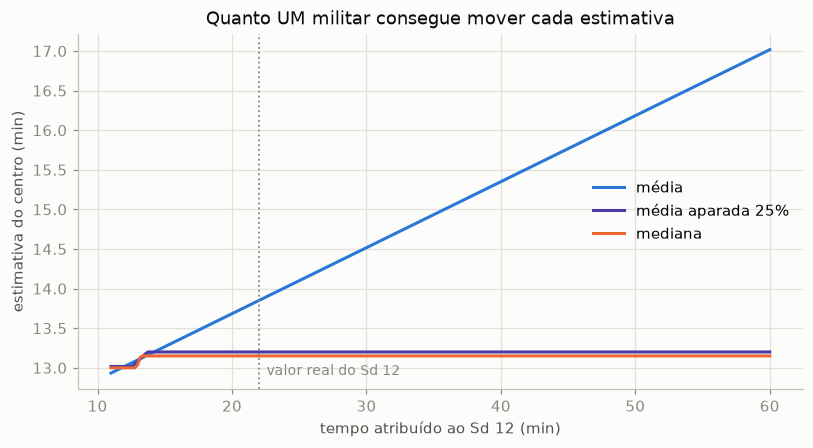

MÉDIA:   uma reta que sobe para sempre. Um único militar tem influência ILIMITADA —
         me dê o valor que eu quiser nele e eu levo a média para onde eu quiser.
MEDIANA e APARADA: sobem enquanto o valor está DENTRO do grupo e TRAVAM assim que ele sai.
         Influência LIMITADA. É exatamente isso que a palavra 'robusto' significa.

A diferença entre as duas aqui não é o formato, é o NÍVEL: a aparada 25% ainda
resume 6 militares; a mediana, apenas 2. Volte a isso na seção 2.3.


In [11]:
# --- Arrastando o Sd 12 de 11 até 60 minutos ---
valores = np.linspace(11, 60, 250)
medias, medianas, aparadas = [], [], []

for v in valores:
    x = t.copy()
    x[11] = v                                  # muda só o Sd 12
    medias.append(x.mean())
    medianas.append(np.median(x))
    aparadas.append(stats.trim_mean(x, 0.25))  # descarta 25% de cada ponta

plt.figure(figsize=(8.5, 4.2))
plt.plot(valores, medias,   color=COR["media"],   label="média")
plt.plot(valores, aparadas, color=COR["aparada"], label="média aparada 25%")
plt.plot(valores, medianas, color=COR["mediana"], label="mediana")
plt.axvline(22.0, color="#898781", linestyle=":", linewidth=1.2)
plt.annotate("valor real do Sd 12", xy=(22, 0.04), xycoords=("data", "axes fraction"),
             xytext=(5, 0), textcoords="offset points", color="#898781", fontsize=9)
plt.title("Quanto UM militar consegue mover cada estimativa", color="#0b0b0b")
plt.xlabel("tempo atribuído ao Sd 12 (min)")
plt.ylabel("estimativa do centro (min)")
plt.legend(frameon=False)
plt.show()

print("MÉDIA:   uma reta que sobe para sempre. Um único militar tem influência ILIMITADA —")
print("         me dê o valor que eu quiser nele e eu levo a média para onde eu quiser.")
print("MEDIANA e APARADA: sobem enquanto o valor está DENTRO do grupo e TRAVAM assim que ele sai.")
print("         Influência LIMITADA. É exatamente isso que a palavra 'robusto' significa.")
print()
print("A diferença entre as duas aqui não é o formato, é o NÍVEL: a aparada 25% ainda")
print("resume 6 militares; a mediana, apenas 2. Volte a isso na seção 2.3.")

## 2.3 · O preço: **eficiência**

Se a mediana é tão mais segura, por que não usar sempre?

Porque quando os dados **estão limpos**, a mediana é uma estimativa mais **imprecisa**: ela joga
fora informação (só olha o meio da fila). Vamos medir isso do jeito honesto — **simulando**.

Repetimos 20.000 vezes o seguinte experimento: sortear um pelotão de 12 militares de uma
população cujo centro **verdadeiro** é conhecido (13,0 min), estimar o centro pelos três métodos
e ver **quem chega mais perto**, em média.

In [12]:
# --- Simulação: quem erra menos o centro VERDADEIRO (13,0 min)? ---
rng = np.random.default_rng(7)
N_SIM, N_MIL, CENTRO = 20_000, 12, 13.0

# erro típico = raiz do erro quadrático médio em relação ao centro verdadeiro
def erro_tipico(estimativas):
    return np.sqrt(np.mean((estimativas - CENTRO) ** 2))

# Cenário 1: pelotões "comportados"
limpo = rng.normal(CENTRO, 0.6, size=(N_SIM, N_MIL))

# Cenário 2: 1 em cada 12 militares tem um problema que joga o tempo pra cima
sujo = limpo.copy()
problema = rng.random((N_SIM, N_MIL)) < 1 / 12
sujo[problema] += rng.normal(6.0, 2.0, size=problema.sum())

resultado = {}
print(f"{'cenário':<24} | {'média':>7} | {'aparada':>7} | {'mediana':>7}")
print("-" * 56)
for nome, amostras in [("dados limpos", limpo), ("1 em 12 contaminado", sujo)]:
    e_med = erro_tipico(amostras.mean(axis=1))
    e_apa = erro_tipico(stats.trim_mean(amostras, 0.25, axis=1))
    e_mdn = erro_tipico(np.median(amostras, axis=1))
    resultado[nome] = (e_med, e_apa, e_mdn)
    print(f"{nome:<24} | {e_med:>7.3f} | {e_apa:>7.3f} | {e_mdn:>7.3f}")

print("\n(números = erro típico da estimativa, em minutos. MENOR é melhor.)")

# --- Traduzindo o preço da robustez para uma unidade que o comando entende: EFETIVO ---
e_med, e_apa, e_mdn = resultado["dados limpos"]
print(f"\nNOS DADOS LIMPOS a mediana erra {(e_mdn / e_med - 1) * 100:.0f}% mais que a média.")
print(f"Para a MEDIANA ficar tão precisa quanto a média com {N_MIL} militares,")
print(f"você precisaria medir ~{N_MIL * (e_mdn / e_med) ** 2:.0f} militares. A APARADA precisaria de ~{N_MIL * (e_apa / e_med) ** 2:.0f}.")
print("Isso é pista, cronômetro, pessoal e tempo — o preço do seguro, em efetivo.")

cenário                  |   média | aparada | mediana
--------------------------------------------------------
dados limpos             |   0.174 |   0.189 |   0.206
1 em 12 contaminado      |   0.738 |   0.264 |   0.246

(números = erro típico da estimativa, em minutos. MENOR é melhor.)

NOS DADOS LIMPOS a mediana erra 19% mais que a média.
Para a MEDIANA ficar tão precisa quanto a média com 12 militares,
você precisaria medir ~17 militares. A APARADA precisaria de ~14.
Isso é pista, cronômetro, pessoal e tempo — o preço do seguro, em efetivo.


### Leia a tabela com atenção — ela derruba as duas simplificações

**Nos dados limpos**, a média ganha: a mediana erra mais. Ela **desperdiça** dados — e a última
linha da saída traduz esse desperdício em efetivo: quantos militares a mais você teria que medir
para a mediana alcançar a precisão da média.

**Nos dados contaminados**, a ordem inverte e a média desaba.

> ### 🔑 Não existe "use sempre a mediana"
> A mediana é uma **apólice de seguro**: você paga um prêmio (precisão) em todos os cenários
> para não quebrar no cenário ruim. Se você **sabe** que seus dados são limpos, pagar o seguro é
> desperdício. Se não sabe — e normalmente não sabe — o seguro é barato perto do prejuízo.
>
> E repare na coluna do meio: a **média aparada** perde pouquíssimo no cenário limpo e segura
> bem o cenário sujo. Ela quase sempre é a escolha profissional.

## 2.4 · Média e mediana são **o mesmo dial**, em posições diferentes

A média aparada tem um parâmetro: quanto cortar de cada ponta.

- corte **0%** → você não descarta ninguém → **é a média**;
- corte **50%** → você descarta tudo menos o miolo → **é a mediana**.

Ou seja: não são duas ferramentas rivais. São **os dois extremos de um mesmo botão**, e você pode
parar em qualquer ponto do meio.

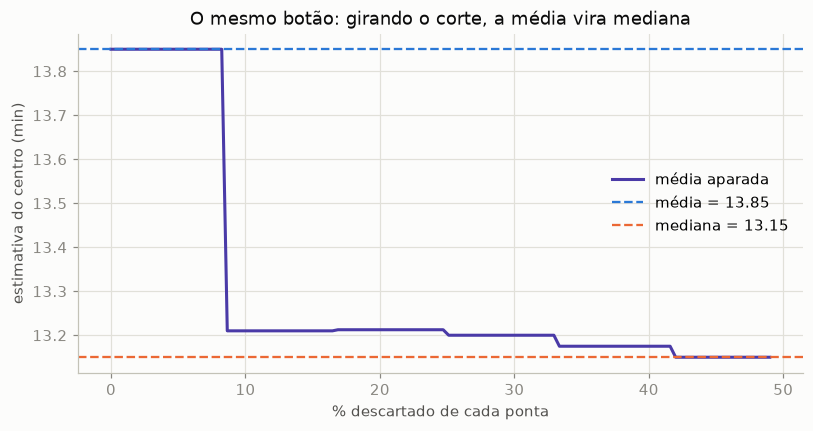

A curva desce em DEGRAUS porque, com 12 militares, cada degrau é 1 militar saindo da conta.


In [13]:
# --- Girando o dial de 0% (média) até quase 50% (mediana) ---
proporcoes = np.linspace(0, 0.49, 120)
dial = [stats.trim_mean(t, p) for p in proporcoes]

plt.figure(figsize=(8.5, 4))
plt.plot(proporcoes * 100, dial, color=COR["aparada"], label="média aparada")
plt.axhline(t.mean(),   color=COR["media"],   linestyle="--", linewidth=1.5, label=f"média = {t.mean():.2f}")
plt.axhline(np.median(t), color=COR["mediana"], linestyle="--", linewidth=1.5, label=f"mediana = {np.median(t):.2f}")
plt.title("O mesmo botão: girando o corte, a média vira mediana", color="#0b0b0b")
plt.xlabel("% descartado de cada ponta")
plt.ylabel("estimativa do centro (min)")
plt.legend(frameon=False)
plt.show()

print("A curva desce em DEGRAUS porque, com 12 militares, cada degrau é 1 militar saindo da conta.")

---
# ③ A família das médias: aritmética não é a única

Até aqui, "média" significou sempre "somar e dividir". Mas somar nem sempre é a operação que faz
sentido — e quando não é, a média aritmética **dá a resposta errada**. Não imprecisa: errada.

## 3.1 · O problema da patrulha (média harmônica)

Um militar corre **3 km a 10 km/h** e volta os mesmos **3 km a 15 km/h**.

**Qual foi a velocidade média dele?** Escreva sua resposta antes de rodar a célula.

In [14]:
# --- Velocidade média na ida e volta ---
distancia, v_ida, v_volta = 3.0, 10.0, 15.0

tempo_total = distancia / v_ida + distancia / v_volta
velocidade_real = (2 * distancia) / tempo_total

print(f"tempo na ida   : {distancia / v_ida * 60:.0f} min")
print(f"tempo na volta : {distancia / v_volta * 60:.0f} min")
print(f"total: 6 km em {tempo_total * 60:.0f} min")
print()
print(f"velocidade média DE VERDADE   : {velocidade_real:.2f} km/h")
print(f"média aritmética (10+15)/2    : {(v_ida + v_volta) / 2:.2f} km/h   <- ERRADO")
print(f"média harmônica               : {stats.hmean([v_ida, v_volta]):.2f} km/h   <- certo")
print()
print("Por quê? Porque ele passou MAIS TEMPO no trecho lento. Somar velocidades")
print("não significa nada — o que soma de verdade é TEMPO.")

tempo na ida   : 18 min
tempo na volta : 12 min
total: 6 km em 30 min

velocidade média DE VERDADE   : 12.00 km/h
média aritmética (10+15)/2    : 12.50 km/h   <- ERRADO
média harmônica               : 12.00 km/h   <- certo

Por quê? Porque ele passou MAIS TEMPO no trecho lento. Somar velocidades
não significa nada — o que soma de verdade é TEMPO.


## 3.2 · O problema do efetivo (média geométrica)

O efetivo de uma OM variou assim em 3 anos: **+50%**, depois **−30%**, depois **+20%**.
Qual foi o crescimento **médio anual**?

In [15]:
# --- Crescimento médio anual do efetivo ---
fatores = np.array([1.50, 0.70, 1.20])   # +50%, -30%, +20%
inicial = 100

final = inicial * fatores.prod()
print(f"efetivo: {inicial} → {inicial*fatores[0]:.0f} → {inicial*fatores[:2].prod():.0f} → {final:.0f}")
print()

aritmetica  = fatores.mean()
geometrica  = stats.gmean(fatores)

print(f"média aritmética dos fatores: {aritmetica:.4f}  ({(aritmetica-1)*100:+.1f}% ao ano)")
print(f"   projeção em 3 anos: {inicial} × {aritmetica:.4f}³ = {inicial*aritmetica**3:.1f}   <- ERRADO (o real foi {final:.0f})")
print()
print(f"média geométrica dos fatores: {geometrica:.4f}  ({(geometrica-1)*100:+.1f}% ao ano)")
print(f"   projeção em 3 anos: {inicial} × {geometrica:.4f}³ = {inicial*geometrica**3:.1f}   <- exato ✅")
print()
print("Crescimento se ACUMULA por multiplicação, não por soma. Logo, a média certa")
print("é a que 'desfaz' multiplicação: a geométrica.")

efetivo: 100 → 150 → 105 → 126

média aritmética dos fatores: 1.1333  (+13.3% ao ano)
   projeção em 3 anos: 100 × 1.1333³ = 145.6   <- ERRADO (o real foi 126)

média geométrica dos fatores: 1.0801  (+8.0% ao ano)
   projeção em 3 anos: 100 × 1.0801³ = 126.0   <- exato ✅

Crescimento se ACUMULA por multiplicação, não por soma. Logo, a média certa
é a que 'desfaz' multiplicação: a geométrica.


## 3.3 · A regra que unifica tudo

As três médias são **a mesma operação**, executada em escalas diferentes:

| Média | Fórmula | Ela é a média aritmética... | Use quando o que soma é |
|---|---|---|---|
| **Aritmética** | `média(x)` | ...de `x` | o próprio valor (peso, flexões, custo) |
| **Geométrica** | `exp(média(log x))` | ...dos **logaritmos** | o **fator** (crescimento, juros, índices) |
| **Harmônica** | `1 / média(1/x)` | ...dos **inversos** | o **inverso** (velocidade, produtividade, taxa) |

> **Regra prática:** transforme para a escala em que **somar faz sentido**, tire a média
> aritmética lá, e volte. Essa é a definição da média certa.

E vale sempre, para qualquer conjunto de valores positivos: **harmônica ≤ geométrica ≤ aritmética**,
com igualdade só quando todos os valores são iguais.

In [16]:
# --- As três médias dos tempos do pelotão, cada uma como 'aritmética em outra escala' ---
print(f"harmônica  = 1 / média(1/x)    = {1 / np.mean(1 / t):.4f}  (scipy: {stats.hmean(t):.4f})")
print(f"geométrica = exp(média(log x)) = {np.exp(np.mean(np.log(t))):.4f}  (scipy: {stats.gmean(t):.4f})")
print(f"aritmética = média(x)          = {t.mean():.4f}")
print()
print("Ordem confirmada: harmônica ≤ geométrica ≤ aritmética.")
print("A distância entre elas cresce com a DISPERSÃO dos dados — o que já é o assunto do Módulo 2.")

harmônica  = 1 / média(1/x)    = 13.5397  (scipy: 13.5397)
geométrica = exp(média(log x)) = 13.6743  (scipy: 13.6743)
aritmética = média(x)          = 13.8500

Ordem confirmada: harmônica ≤ geométrica ≤ aritmética.
A distância entre elas cresce com a DISPERSÃO dos dados — o que já é o assunto do Módulo 2.


---
# ④ Quando o centro não existe

Todas as medidas acima respondem "qual é o valor típico?". A pergunta que ninguém faz antes é:

> **Existe um valor típico?**

Às vezes a resposta é não — e aí qualquer medida de centro produz um número que descreve
**ninguém**.

## 4.1 · O caso do piloto médio (USAF, 1950) — história real

Nos anos 1940 a Força Aérea americana sofria uma epidemia de acidentes sem falha mecânica
aparente. As cabines tinham sido dimensionadas em 1926 com base no **piloto médio**.

O tenente **Gilbert S. Daniels** mediu **4.063 pilotos** em 10 dimensões corporais e fez uma
pergunta simples: quantos deles são "médios" (dentro da faixa central de 30%) nas **10** dimensões
ao mesmo tempo?

A resposta foi **zero**. Nenhum piloto entre 4.063.

Vamos reproduzir a lógica com um efetivo simulado de 500 militares.

In [17]:
# --- Quantos militares são "médios" em TODAS as medidas ao mesmo tempo? ---
rng = np.random.default_rng(2)
N_MILITARES = 500

corpo = pd.DataFrame({
    "altura":  rng.normal(175, 7, N_MILITARES),
    "peso":    rng.normal(78, 9, N_MILITARES),
    "tórax":   rng.normal(96, 6, N_MILITARES),
    "braço":   rng.normal(33, 3, N_MILITARES),
    "perna":   rng.normal(84, 5, N_MILITARES),
    "cabeça":  rng.normal(57, 2, N_MILITARES),
})

# "médio" nesta medida = dentro dos 30% centrais (entre os percentis 35 e 65)
dentro = (corpo >= corpo.quantile(0.35)) & (corpo <= corpo.quantile(0.65))

print(f"De {N_MILITARES} militares, quantos são 'médios' simultaneamente em...")
for k in range(1, corpo.shape[1] + 1):
    quantos = dentro.iloc[:, :k].all(axis=1).sum()
    medidas = ", ".join(corpo.columns[:k])
    print(f"  {k} medida(s): {quantos:>3}  ({medidas})")

print("\nCada medida a mais corta ~70% dos sobreviventes. O 'militar médio' evapora.")
print("Nota: aqui as medidas são independentes; no corpo real elas são correlacionadas")
print("e o número cai mais devagar — mas Daniels, com dados REAIS e 10 dimensões, achou ZERO.")
print("\nA solução da USAF não foi mudar o piloto: foi criar o ASSENTO AJUSTÁVEL.")
print("Projetar para a média é projetar para ninguém.")

De 500 militares, quantos são 'médios' simultaneamente em...
  1 medida(s): 150  (altura)
  2 medida(s):  41  (altura, peso)
  3 medida(s):  15  (altura, peso, tórax)
  4 medida(s):   4  (altura, peso, tórax, braço)
  5 medida(s):   1  (altura, peso, tórax, braço, perna)
  6 medida(s):   0  (altura, peso, tórax, braço, perna, cabeça)

Cada medida a mais corta ~70% dos sobreviventes. O 'militar médio' evapora.
Nota: aqui as medidas são independentes; no corpo real elas são correlacionadas
e o número cai mais devagar — mas Daniels, com dados REAIS e 10 dimensões, achou ZERO.

A solução da USAF não foi mudar o piloto: foi criar o ASSENTO AJUSTÁVEL.
Projetar para a média é projetar para ninguém.


## 4.2 · Duas populações misturadas (bimodalidade)

A companhia reuniu 30 **veteranos** e 30 **recrutas** no mesmo TAF.
A média e a mediana vão concordar entre si — e as duas vão estar erradas.

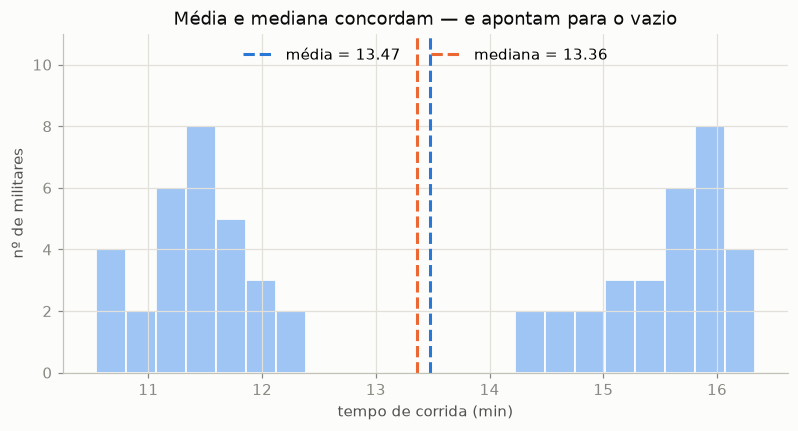

Militares a menos de 30 s do 'tempo médio' de 13.47 min: 0 de 60

As duas medidas estão 'certas' pela fórmula e inúteis pela realidade.
A resposta honesta ao comando não é um número — é: 'são DOIS grupos, e cada um
tem o seu centro: veteranos ~11,5 min e recrutas ~15,5 min'.

Nenhuma medida de centro te avisa disso sozinha. O HISTOGRAMA avisa.
Por isso a regra: OLHE A DISTRIBUIÇÃO antes de resumir.


In [18]:
# --- Uma companhia com dois grupos bem distintos ---
rng = np.random.default_rng(11)
veteranos = rng.normal(11.5, 0.5, 30)
recrutas  = rng.normal(15.5, 0.6, 30)
companhia = np.concatenate([veteranos, recrutas])

media_c, mediana_c = companhia.mean(), np.median(companhia)

plt.figure(figsize=(8.5, 4))
plt.hist(companhia, bins=22, color=COR["dados"], edgecolor="#fcfcfb", linewidth=1.2)
plt.axvline(media_c,   color=COR["media"],   linestyle="--", label=f"média = {media_c:.2f}")
plt.axvline(mediana_c, color=COR["mediana"], linestyle="--", label=f"mediana = {mediana_c:.2f}")
plt.title("Média e mediana concordam — e apontam para o vazio", color="#0b0b0b")
plt.xlabel("tempo de corrida (min)")
plt.ylabel("nº de militares")
plt.ylim(top=11)
plt.legend(frameon=False, loc="upper center", ncol=2)
plt.show()

na_faixa = np.sum((companhia > media_c - 0.5) & (companhia < media_c + 0.5))
print(f"Militares a menos de 30 s do 'tempo médio' de {media_c:.2f} min: {na_faixa} de {len(companhia)}")
print("\nAs duas medidas estão 'certas' pela fórmula e inúteis pela realidade.")
print("A resposta honesta ao comando não é um número — é: 'são DOIS grupos, e cada um")
print("tem o seu centro: veteranos ~11,5 min e recrutas ~15,5 min'.")
print("\nNenhuma medida de centro te avisa disso sozinha. O HISTOGRAMA avisa.")
print("Por isso a regra: OLHE A DISTRIBUIÇÃO antes de resumir.")

## 4.3 · 💡 Bônus — casos em que a média nem sequer existe

*(Opcional, mas vale os 2 minutos.)*

Existem distribuições de cauda muito pesada — comuns em prejuízos financeiros, tempos de
espera em rede e tamanho de arquivos — em que a média populacional **não existe
matematicamente**. Na prática isso aparece assim: quanto mais dados você coleta, **menos** a
média se estabiliza.

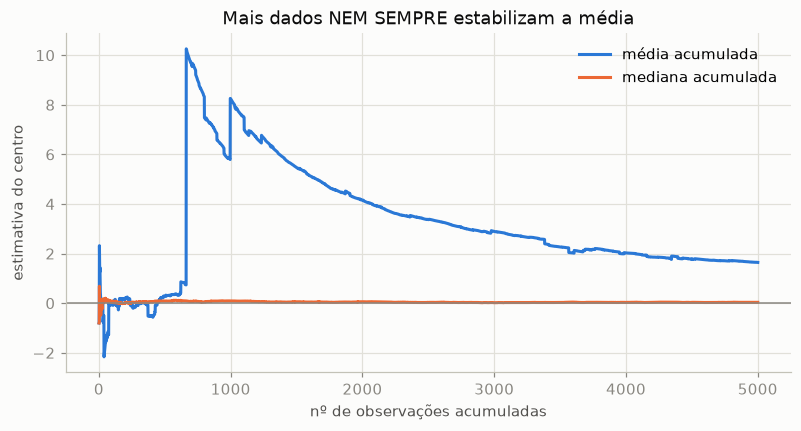

A mediana converge tranquilamente para o centro (0). A média dá saltos para sempre.
Não é falta de dados: é que a média dessa distribuição NÃO EXISTE.
A mediana existe sempre. Esse é o argumento mais forte a favor dela.


In [19]:
# --- Média acumulada em uma distribuição de cauda pesada (Cauchy) ---
rng = np.random.default_rng(3)
amostra = rng.standard_cauchy(5000)

n_ = np.arange(1, 5001)
media_acumulada   = np.cumsum(amostra) / n_
mediana_acumulada = np.array([np.median(amostra[:i]) for i in n_])

plt.figure(figsize=(8.5, 4))
plt.plot(n_, media_acumulada,   color=COR["media"],   label="média acumulada")
plt.plot(n_, mediana_acumulada, color=COR["mediana"], label="mediana acumulada")
plt.axhline(0, color="#898781", linewidth=1)
plt.title("Mais dados NEM SEMPRE estabilizam a média", color="#0b0b0b")
plt.xlabel("nº de observações acumuladas")
plt.ylabel("estimativa do centro")
plt.legend(frameon=False)
plt.show()

print("A mediana converge tranquilamente para o centro (0). A média dá saltos para sempre.")
print("Não é falta de dados: é que a média dessa distribuição NÃO EXISTE.")
print("A mediana existe sempre. Esse é o argumento mais forte a favor dela.")

---
# ⑤ Decisão: o que reportar ao comando

Volte à pergunta original: *"qual é o tempo típico de corrida deste pelotão?"*

| A pergunta real é... | Reporte | Por quê |
|---|---|---|
| quanto o pelotão consome/produz **no total** | **média** | é a única ligada à soma (§1.1) |
| vou **consolidar** com outras frações | **média** | é a única que se agrega (§1.2) |
| qual o desempenho do militar **típico** | **mediana** ou **aparada** | não deixa 1 lesionado falar por 12 (§2.1) |
| qual **taxa/velocidade** média | **harmônica** | velocidade não soma (§3.1) |
| qual **crescimento** médio | **geométrica** | crescimento multiplica (§3.2) |
| qual a categoria mais comum | **moda** | é a única que existe em escala nominal (§1.4) |
| os dados têm **dois grupos**? | **nenhuma** — reporte os dois | o centro não existe (§4.2) |

### Três frases para levar

1. **Escolher a medida é escolher como o erro te machuca** — não é questão de gosto nem de rotina.
2. **Sempre olhe a distribuição antes de resumir.** Nenhuma medida de centro te avisa sozinha que
   ela é inadequada.
3. **Reporte a medida com o contexto.** "Mediana de 13,1 min (a média é 13,9 min, puxada por um
   militar lesionado)" é uma frase que informa. Um número solto engana — inclusive quem o escreveu.

---
# ⑥ Exercícios

Lembre: você **não vai escrever código do zero**. Vai **prever**, **modificar**, **consertar** e **interpretar**.

**Exercício 1 — Preveja antes de rodar.**

O Sd 12 fez **20 flexões**. Suponha que na verdade ele tenha feito **2**.
Antes de executar, escreva no papel o que acontece com **cada uma das três curvas de custo** da seção ⓪:

1. O fundo do vale de qual(is) curva(s) se desloca?
2. Em que direção?
3. Alguma curva fica **exatamente** igual?

In [20]:
# EXERCÍCIO 1 — rode e compare com a sua previsão
# lembre: o fundo do vale da curva A é a MÉDIA, o da B é a MEDIANA, o da C é a MODA.
f_ex1 = f.copy()
f_ex1[11] = 2            # Sd 12: 20 -> 2 flexões

print(f"{'':<10} | {'ANTES':>7} | {'DEPOIS':>7}")
print("-" * 30)
print(f"{'média':<10} | {f.mean():>7.2f} | {f_ex1.mean():>7.2f}")
print(f"{'mediana':<10} | {np.median(f):>7.2f} | {np.median(f_ex1):>7.2f}")
print(f"{'moda':<10} | {pd.Series(f).mode().iloc[0]:>7.0f} | {pd.Series(f_ex1).mode().iloc[0]:>7.0f}")

           |   ANTES |  DEPOIS
------------------------------
média      |   38.83 |   37.33
mediana    |   39.50 |   39.50
moda       |      38 |      38


**Exercício 2 — Ache o ponto de ruptura na mão.**

Na célula abaixo, mude `K` (quantos militares tiveram o tempo corrompido para 100 min).
Encontre o **menor K** que faz a **mediana** passar de 20 min.

Depois responda: esse K corresponde a que **fração** do pelotão? Bate com o valor teórico da seção 2.1?

In [21]:
# EXERCÍCIO 2 — mude o K e rode de novo
K = 1   # <-- MUDE AQUI (0 a 12)

x_ex2 = np.sort(t).copy()
if K > 0:
    x_ex2[-K:] = 100.0

print(f"Com K = {K} ({K/len(t)*100:.0f}% do pelotão corrompido):")
print(f"  média   = {x_ex2.mean():>7.2f}")
print(f"  mediana = {np.median(x_ex2):>7.2f}   {'<-- QUEBROU' if np.median(x_ex2) > 20 else ''}")

Com K = 1 (8% do pelotão corrompido):
  média   =   20.35
  mediana =   13.15   


**Exercício 3 — Conserte o erro (é conceitual, não de sintaxe).**

A célula abaixo roda sem erro nenhum e devolve um número **errado**.
Uma patrulha percorreu **3 trechos de 4 km cada**, nas velocidades indicadas.

Descubra o erro e corrija. *(Dica: releia a seção 3.1 e pergunte-se o que realmente soma aqui.)*
A conferência no final da célula já está correta — use-a para validar sua correção.

In [22]:
# EXERCÍCIO 3 — o resultado sai, mas está errado. Conserte.
velocidades = np.array([6.0, 4.0, 12.0])   # km/h em cada trecho de 4 km

velocidade_media = velocidades.mean()      # <-- o erro está NESTA linha
print(f"velocidade média da patrulha: {velocidade_media:.2f} km/h")

# --- conferência (não mexa): 12 km percorridos dividido pelo tempo total gasto ---
tempo_total_h = np.sum(4.0 / velocidades)
print(f"conferência ......................: {12.0 / tempo_total_h:.2f} km/h")

velocidade média da patrulha: 7.33 km/h
conferência ......................: 6.00 km/h


**Exercício 4 — Escolha a medida (sem código).**

Para cada situação, diga **qual medida** você usaria e **por quê** em uma frase:

1. O S4 precisa saber quantas rações pedir para o próximo exercício, sabendo o consumo diário de cada militar.
2. O comandante quer saber quanto tempo um militar "normal" leva para completar a pista, sabendo que dois estão em recuperação de lesão.
3. Uma viatura fez 60 km a 80 km/h e mais 60 km a 40 km/h. Qual a velocidade média?
4. O efetivo do batalhão cresceu 10%, 5% e 20% nos últimos três anos. Qual o crescimento médio anual?
5. Você precisa dimensionar o estoque do almoxarifado por **numeração de coturno**.
6. Duas turmas fizeram o TAF: uma de recrutas e uma de veteranos, mas os dados vieram misturados num arquivo só.

**Exercício 5 — Defenda ou critique (discussão em grupo).**

Um colega reportou ao comando: *"o tempo típico do pelotão é 13,05 min (média aparada a 25%)"*.

1. Essa escolha é defensável? Contra o que ela protege e o que ela custa?
2. Que **uma** informação adicional você exigiria antes de aceitar esse número como suficiente?
3. Se o comando fosse usar esse número para **dimensionar o tempo total de uso da pista**
   pelos 12 militares, ele ainda serve? Justifique.

---
## Resumo do módulo

| Medida | Minimiza | Ponto de ruptura | Faz o que ninguém mais faz |
|---|---|---|---|
| **Média** | Σ (erro)² | 0% | conversa com o **total** e se **agrega** entre grupos |
| **Mediana** | Σ \|erro\| | 50% | **atravessa** transformações de escala e resiste a extremos |
| **Moda** | nº de erros | — | existe em dados **nominais** e denuncia **bimodalidade** |
| **Aparada** | (dial entre as duas) | ajustável | equilíbrio prático entre precisão e proteção |
| **Geométrica** | — | — | trata o que **multiplica** (crescimento) |
| **Harmônica** | — | — | trata o que é **taxa** (velocidade) |

- Escolher a medida = escolher **como o erro te machuca**.
- Robustez **tem preço**; a média aparada costuma ser o melhor negócio.
- Antes de resumir, pergunte se **existe** um centro. Olhe o histograma.

➡️ **Próximo módulo:** dois pelotões podem ter **exatamente a mesma média e a mesma mediana**
e ainda assim serem completamente diferentes. Uma medida de centro **sempre** precisa vir
acompanhada de uma medida de **variabilidade** — e esse é o Módulo 2.